# Live analysis — daily charts from Kaggle agent logs

Parses `[exec] … PASS`, `[snap] …`, and day-0 `[planner]` placement lines from `kaggle competitions logs` JSON.

**Note:** Older logs without `[snap]` lines only populate the PASS panel. Re-run after a submission that includes the snap logger.

In [4]:
filepath = "submissions/260813_5/92618307-0.json"

In [5]:
import json
import re
import sys
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().resolve()
if not (ROOT / "agent").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from agent import animal_rollouts, rollouts

LOG_PATH = ROOT / filepath
PASS_RE = re.compile(r"\[exec\] d=(\d+) h=(\d+) (farmer|hand\d+) PASS")
SNAP_RE = re.compile(r"\[snap\] d=(\d+) h=(\d+) money=(\d+)(?: (.+))?")
PLAN_RE = re.compile(r"^\s+(crop|animal) (\w+) (\S+) tile=(\d+) start=(\d+)$")
PLAN_HEADER_RE = re.compile(r"\[planner\] day=0\b.*selected=(\d+)")
REWARD_RE = re.compile(r"Player 0: reward=([\d.]+)")
ZONE_WORKERS = ("farmer", "hire1", "hire2", "hire3")
ZONE_EMPTY_COLS = tuple(f"{w}_empty" for w in ZONE_WORKERS)
DEMAND_PREFIX = "demand_"
NUM_TILES = 25
SEASON_DAYS = 30


def load_stdout_lines(path: Path) -> list[str]:
    with open(path, encoding="utf-8") as f:
        steps = json.load(f)
    lines: list[str] = []
    for step in steps:
        if isinstance(step, list):
            for item in step:
                if isinstance(item, dict) and item.get("stdout"):
                    lines.extend(item["stdout"].splitlines())
        elif isinstance(step, dict) and step.get("stdout"):
            lines.extend(step["stdout"].splitlines())
    return lines


def parse_passes(lines: list[str]) -> pd.DataFrame:
    counts: dict[tuple[int, str], int] = defaultdict(int)
    for line in lines:
        m = PASS_RE.search(line)
        if m:
            counts[(int(m.group(1)), m.group(3))] += 1
    if not counts:
        return pd.DataFrame(columns=["day", "worker", "passes"])
    rows = [
        {"day": day, "worker": worker, "passes": n}
        for (day, worker), n in sorted(counts.items())
    ]
    return pd.DataFrame(rows)


def parse_snaps(lines: list[str]) -> pd.DataFrame:
    rows: list[dict] = []
    for line in lines:
        m = SNAP_RE.search(line)
        if not m:
            continue
        row = {
            "day": int(m.group(1)),
            "hour": int(m.group(2)),
            "money": int(m.group(3)),
        }
        tail = m.group(4) or ""
        for part in tail.split():
            if "=" in part:
                key, val = part.split("=", 1)
                row[key] = int(val)
        rows.append(row)
    return pd.DataFrame(rows)


def parse_final_reward(lines: list[str]) -> float | None:
    for line in reversed(lines):
        m = REWARD_RE.search(line)
        if m:
            return float(m.group(1))
    return None


def _plan_bar_end(kind: str, label: str, profile: str, start: int) -> int:
    if kind == "crop":
        days = rollouts.covered_days(label, start, SEASON_DAYS, profile)
    else:
        days = animal_rollouts.covered_days(label, start, SEASON_DAYS, profile)
    if not days:
        return start + 1
    return max(days) + 1


def parse_initial_plan(lines: list[str]) -> tuple[pd.DataFrame, int | None]:
    """Parse day-0 planner placements from the first planner block only."""
    rows: list[dict] = []
    selected: int | None = None
    in_block = False
    for line in lines:
        if line.startswith("[planner] day=0"):
            in_block = True
            m = PLAN_HEADER_RE.search(line)
            if m:
                selected = int(m.group(1))
            continue
        if not in_block:
            continue
        if line.startswith("[executor] replan") or line.startswith("[planner] patch"):
            break
        m = PLAN_RE.match(line)
        if not m:
            continue
        kind, label, profile = m.group(1), m.group(2), m.group(3)
        tile = int(m.group(4))
        start = int(m.group(5))
        end = _plan_bar_end(kind, label, profile, start)
        rows.append(
            {
                "kind": kind,
                "label": label,
                "profile": profile,
                "tile": tile,
                "start": start,
                "end": end,
            }
        )
    if selected is None and rows:
        selected = len(rows)
    return pd.DataFrame(rows), selected


lines = load_stdout_lines(LOG_PATH)
passes_df = parse_passes(lines)
snaps_df = parse_snaps(lines)
plan_df, plan_selected = parse_initial_plan(lines)
final_reward = parse_final_reward(lines)
print(
    f"log: {LOG_PATH.name}  lines={len(lines)}  passes={len(passes_df)}  "
    f"snaps={len(snaps_df)}  plan={len(plan_df)} (selected={plan_selected})"
    + (f"  final_reward={final_reward:.0f}" if final_reward is not None else "")
)

log: 92618307-0.json  lines=2907  passes=113  snaps=30  plan=0 (selected=None)


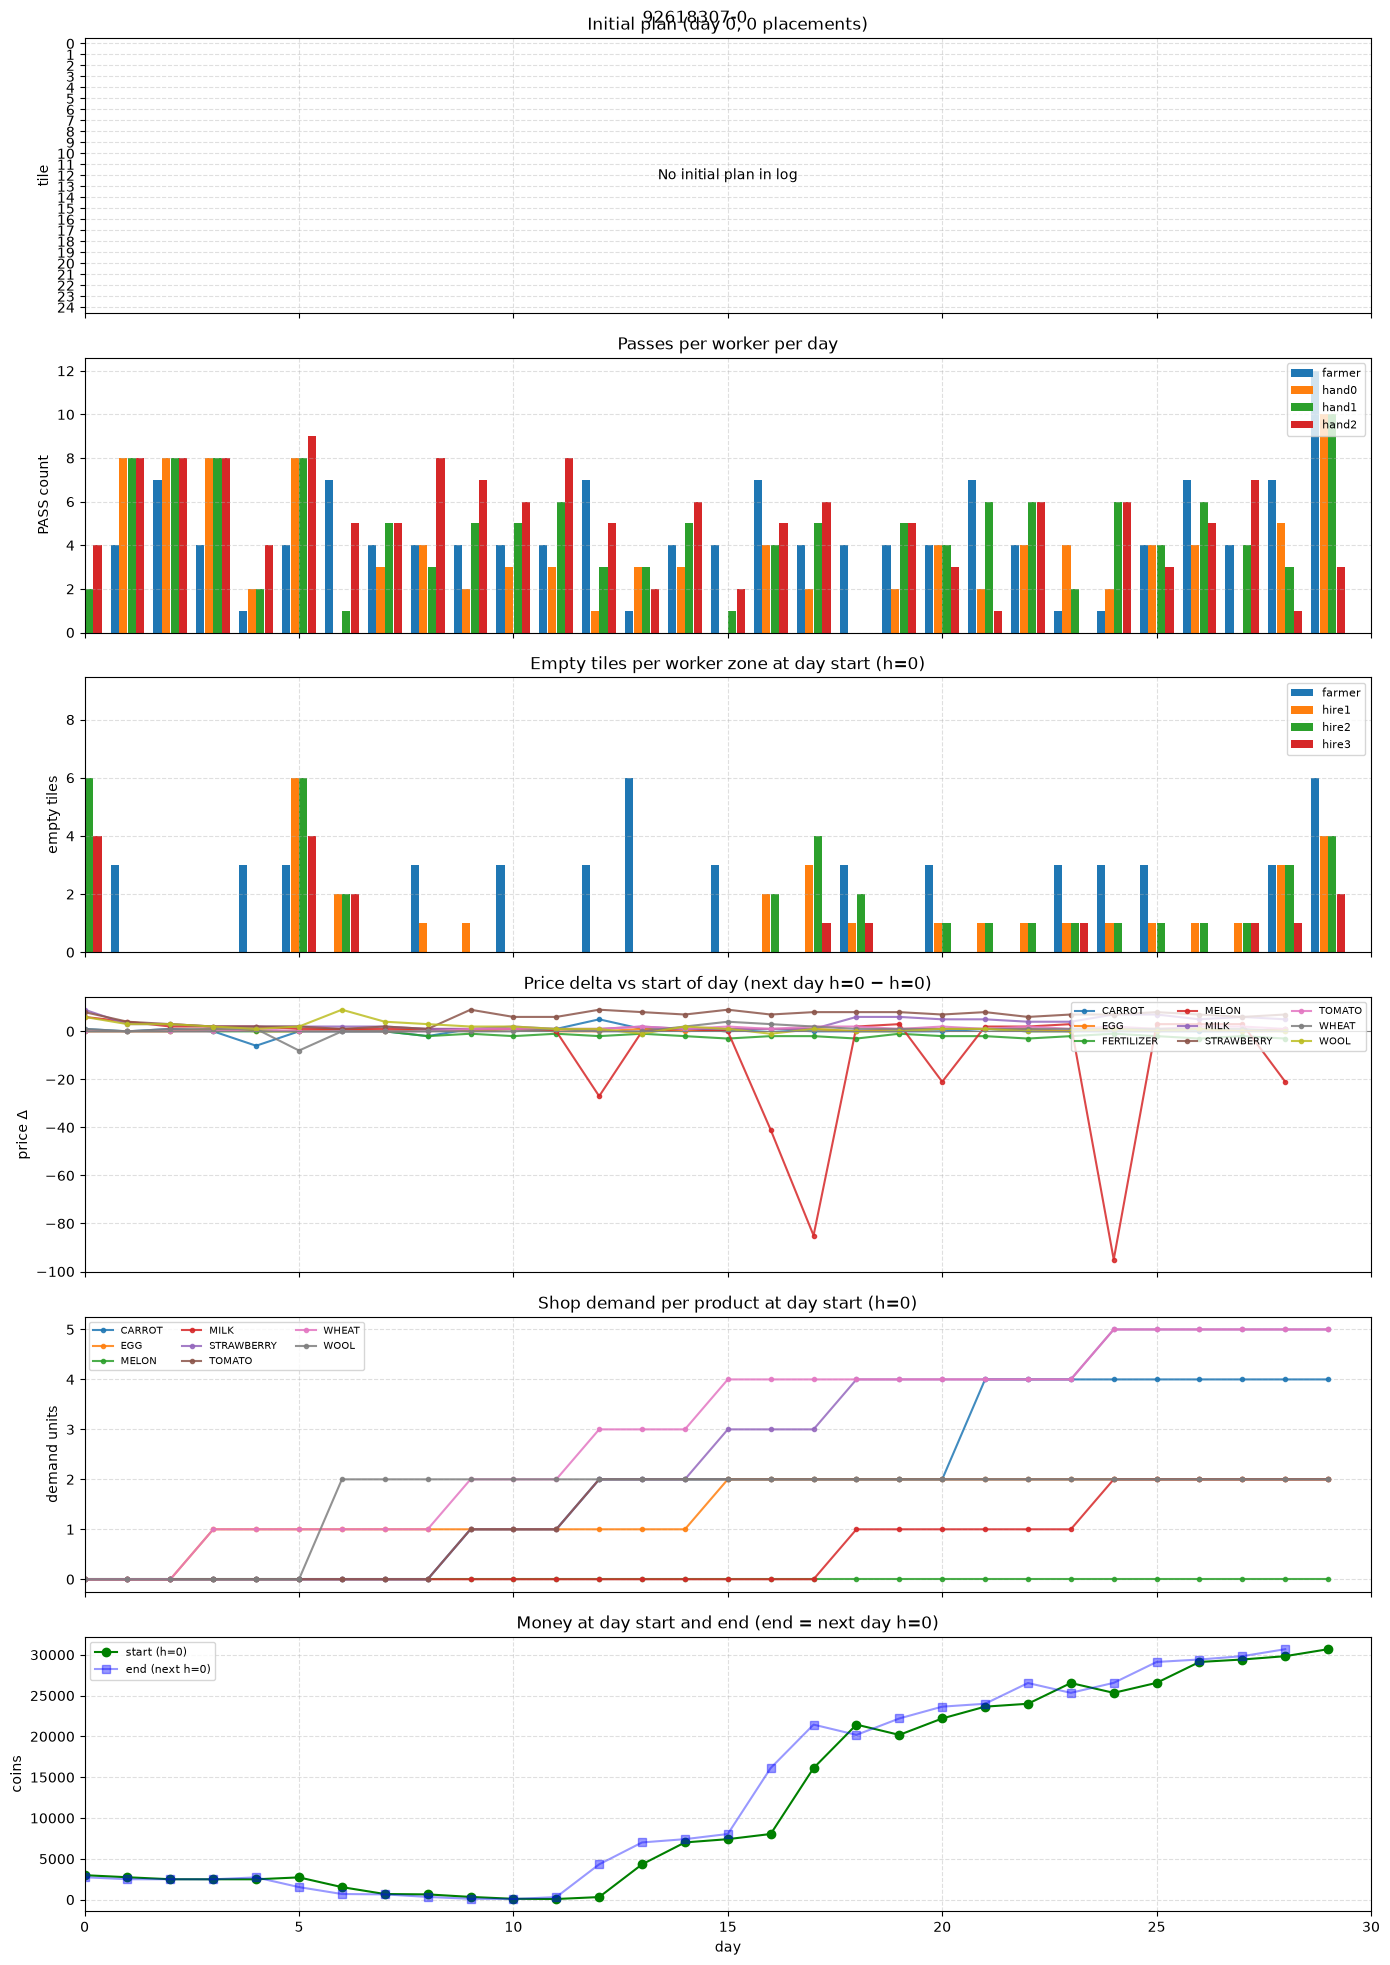

In [6]:
DAYS = list(range(30))

CROP_STYLE = {
    "WHEAT": {"color": "#e8c84a", "hatch": "//"},
    "CARROT": {"color": "#e8913a", "hatch": "\\\\"},
    "TOMATO": {"color": "#8bc34a", "hatch": "xx"},
    "MELON": {"color": "#2e7d32", "hatch": "oo"},
    "STRAWBERRY": {"color": "#d94f4f", "hatch": ".."},
}
ANIMAL_STYLE = {
    "GOOSE": {"color": "#90caf9", "hatch": "//"},
    "COW": {"color": "#8d6e63", "hatch": "xx"},
    "SHEEP": {"color": "#eceff1", "hatch": ".."},
}


def plan_bar_style(row: pd.Series) -> dict:
    if row["kind"] == "crop":
        st = dict(CROP_STYLE.get(row["label"], {"color": "#999999", "hatch": ""}))
    else:
        st = dict(ANIMAL_STYLE.get(row["label"], {"color": "#999999", "hatch": ""}))
    if row["profile"] in ("with_fert", "with_care"):
        st["edgecolor"] = "#1565c0" if row["kind"] == "crop" else "#c62828"
        st["linewidth"] = 1.5
    else:
        st.setdefault("edgecolor", "#333333")
        st.setdefault("linewidth", 0.8)
    return st


def series_by_day(
    df: pd.DataFrame,
    value_col: str,
    day_col: str = "day",
    days: list[int] | None = None,
    fill: float | None = 0,
) -> pd.Series:
    """Reindex one numeric column onto the full day range; missing days get fill."""
    days = days if days is not None else DAYS
    if df.empty or value_col not in df.columns:
        val = fill if fill is not None else float("nan")
        return pd.Series(val, index=days, dtype=float)
    s = df.set_index(day_col)[value_col].astype(float)
    if fill is not None:
        return s.reindex(days, fill_value=fill)
    return s.reindex(days)


def snap_meta_cols(snaps: pd.DataFrame) -> set[str]:
    return {
        "day",
        "hour",
        "money",
        "shops",
        "demand",
        *ZONE_EMPTY_COLS,
        *[c for c in snaps.columns if c.startswith(DEMAND_PREFIX)],
    }


def demand_cols(snaps: pd.DataFrame) -> list[str]:
    return sorted(c for c in snaps.columns if c.startswith(DEMAND_PREFIX))


def price_delta_by_day(snaps: pd.DataFrame) -> pd.DataFrame:
    if snaps.empty:
        return pd.DataFrame()
    price_cols = [c for c in snaps.columns if c not in snap_meta_cols(snaps)]
    if not price_cols:
        return pd.DataFrame()
    start = snaps[snaps["hour"] == 0].set_index("day")
    rows = []
    for day in DAYS:
        if day not in start.index or day + 1 not in start.index:
            continue
        s = start.loc[day]
        e = start.loc[day + 1]
        for col in price_cols:
            if col in s and col in e:
                rows.append(
                    {
                        "day": day,
                        "product": col,
                        "delta": int(e[col]) - int(s[col]),
                    }
                )
    return pd.DataFrame(rows)


def plot_live_analysis(
    passes: pd.DataFrame,
    snaps: pd.DataFrame,
    plan: pd.DataFrame,
    plan_selected: int | None = None,
    final_reward: float | None = None,
) -> None:
    fig, axes = plt.subplots(6, 1, figsize=(14, 20), sharex=True)
    fig.suptitle(LOG_PATH.stem, fontsize=12)

    ax_plan = axes[0]
    if plan.empty:
        ax_plan.text(
            0.5,
            0.5,
            "No initial plan in log",
            ha="center",
            va="center",
            transform=ax_plan.transAxes,
        )
    else:
        for _, row in plan.iterrows():
            st = plan_bar_style(row)
            width = row["end"] - row["start"]
            ax_plan.barh(
                y=row["tile"],
                width=width,
                left=row["start"],
                height=0.8,
                color=st["color"],
                hatch=st.get("hatch", ""),
                edgecolor=st["edgecolor"],
                linewidth=st["linewidth"],
            )
        for zone_line in (8.5, 14.5, 20.5):
            ax_plan.axhline(zone_line, color="gray", linewidth=0.6, alpha=0.5)
    n = plan_selected if plan_selected is not None else len(plan)
    ax_plan.set_ylabel("tile")
    ax_plan.set_yticks(range(NUM_TILES))
    ax_plan.set_ylim(NUM_TILES - 0.5, -0.5)
    ax_plan.set_xlim(0, SEASON_DAYS)
    ax_plan.set_title(f"Initial plan (day 0, {n} placements)")

    ax0 = axes[1]
    if passes.empty:
        ax0.text(0.5, 0.5, "No PASS lines", ha="center", va="center", transform=ax0.transAxes)
    else:
        workers = sorted(passes["worker"].unique(), key=lambda w: (w != "farmer", w))
        width = 0.8 / max(len(workers), 1)
        for i, worker in enumerate(workers):
            sub = passes[passes["worker"] == worker]
            counts = series_by_day(sub, "passes", fill=0)
            offset = (i - (len(workers) - 1) / 2) * width
            ax0.bar([d + offset for d in DAYS], counts.values, width=width * 0.95, label=worker)
        ax0.legend(loc="upper right", fontsize=8)
    ax0.set_ylabel("PASS count")
    ax0.set_title("Passes per worker per day")

    ax1 = axes[2]
    day_snaps = snaps[snaps["hour"] == 0] if not snaps.empty else pd.DataFrame()
    has_zone_empty = not day_snaps.empty and all(
        col in day_snaps.columns for col in ZONE_EMPTY_COLS
    )
    if not has_zone_empty:
        ax1.text(
            0.5,
            0.5,
            "No per-zone empty data (need newer agent logs)",
            ha="center",
            va="center",
            transform=ax1.transAxes,
        )
    else:
        width = 0.8 / len(ZONE_WORKERS)
        for i, worker in enumerate(ZONE_WORKERS):
            col = f"{worker}_empty"
            counts = series_by_day(day_snaps, col, fill=0)
            offset = (i - (len(ZONE_WORKERS) - 1) / 2) * width
            ax1.bar(
                [d + offset for d in DAYS],
                counts.values,
                width=width * 0.95,
                label=worker,
            )
        ax1.legend(loc="upper right", fontsize=8)
    ax1.set_ylabel("empty tiles")
    ax1.set_title("Empty tiles per worker zone at day start (h=0)")

    ax2 = axes[3]
    price_df = price_delta_by_day(snaps)
    if price_df.empty:
        ax2.text(
            0.5,
            0.5,
            "No [snap] price data",
            ha="center",
            va="center",
            transform=ax2.transAxes,
        )
    else:
        for product in sorted(price_df["product"].unique()):
            sub = price_df[price_df["product"] == product]
            deltas = series_by_day(sub, "delta", fill=float("nan"))
            ax2.plot(DAYS, deltas.values, marker=".", label=product, alpha=0.85)
        ax2.axhline(0, color="gray", linewidth=0.8)
        ax2.legend(loc="upper right", fontsize=7, ncol=3)
    ax2.set_ylabel("price Δ")
    ax2.set_title("Price delta vs start of day (next day h=0 − h=0)")

    ax3 = axes[4]
    demand_columns = demand_cols(day_snaps)
    if not demand_columns:
        ax3.text(
            0.5,
            0.5,
            "No per-product demand data (need newer agent logs)",
            ha="center",
            va="center",
            transform=ax3.transAxes,
        )
    else:
        for col in demand_columns:
            product = col.removeprefix(DEMAND_PREFIX)
            values = series_by_day(day_snaps, col, fill=0)
            ax3.plot(DAYS, values.values, marker=".", label=product, alpha=0.85)
        ax3.legend(loc="upper left", fontsize=7, ncol=3)
        ax3.set_ylabel("demand units")
    ax3.set_title("Shop demand per product at day start (h=0)")

    ax4 = axes[5]
    if day_snaps.empty:
        ax4.text(
            0.5,
            0.5,
            "No [snap] money data",
            ha="center",
            va="center",
            transform=ax4.transAxes,
        )
    else:
        money_by_day = day_snaps.set_index("day")["money"].astype(float)
        money_start = series_by_day(day_snaps, "money", fill=float("nan"))
        money_end_vals = [
            float(money_by_day.get(d + 1, float("nan"))) for d in DAYS
        ]
        ax4.plot(
            DAYS,
            money_start.values,
            marker="o",
            color="green",
            label="start (h=0)",
            alpha=1.0,
        )
        ax4.plot(
            DAYS,
            money_end_vals,
            marker="s",
            color="blue",
            label="end (next h=0)",
            alpha=0.4,
        )
        if final_reward is not None:
            ax4.scatter(
                [SEASON_DAYS - 1],
                [final_reward],
                color="red",
                s=60,
                zorder=5,
                label=f"Kaggle score ({final_reward:.0f})",
            )
        ax4.legend(loc="upper left", fontsize=8)
        ax4.set_ylabel("coins")
    ax4.set_title("Money at day start and end (end = next day h=0)")
    ax4.set_xlabel("day")

    for ax in axes:
        ax.grid(True, linestyle="--", alpha=0.4)

    plt.tight_layout()
    plt.show()


plot_live_analysis(passes_df, snaps_df, plan_df, plan_selected, final_reward)